<a href="https://colab.research.google.com/github/manugiraldo123/Integracion-de-datos-y-prospectiva/blob/main/3_Integraci%C3%B3n_Datos_Cosco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso Estudio - Primer Método Integración**

El primer método de integración se conoce como el método de muestreo (muestreo por clusterización - Montecarlo). Este método esta determinado por el índice de confiabilidad. De manera general la confiabilidad a norma internacional esta marcado por una confiabilidad del 99.9%, lo que requerira como minimo tener un total de 1000 datos.

0. Cargamos las librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns  #Las gráficas estadísticas
import matplotlib.pyplot as plt

1. Cargamos los datos de trabajo

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


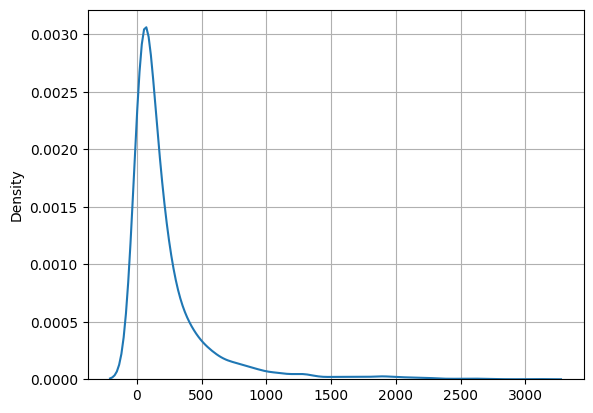

In [2]:
nxl='/content/1. RiesgoOperacional_EVERGREEEN.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
#display(XDB)
Freq=XDB.iloc[:,3]; Sev=XDB.iloc[:,4]
LDA=Freq*Sev

plt.figure()
sns.kdeplot(LDA)
plt.grid()
plt.show()

2. Se procede con la creación de los concentradores de información

In [3]:
import random
random.seed(42)
XC=np.array(random.choices(LDA,k=5))
XC=np.sort(XC)
print("Los concentradores de información son:",XC)

Los concentradores de información son: [ 66.68668397  83.48720974  85.08350368 192.09214682 203.24462183]


3. Se clasifican los datos de acuerdo con los concentradores de información

In [5]:
box0=[];box1=[];box2=[];box3=[];box4=[]
Boxes=[box0,box1,box2,box3,box4]

for k in range(len(LDA)):
  d=np.abs(XC-LDA.iloc[k,])/XC #la distancia de un dato a un concentrador
  nc=np.argmin(d)  #Número de la caja en donde voy a introducir el dato
  #no olvidar actualizar el centroide de la caja
  XC[nc,]= (XC[nc,]+LDA.iloc[k,])/2
  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por Caja
pm=[]  #Vector de porcentajes
for j in range(5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)

pm=(np.array(pm)*1000).astype(int)
print("El porcentaje de los datos es:",pm)

El porcentaje de los datos es: [ 29  58 136 279 495]


4. Sacamos daticos por caja y creamos una LDA2

la media de los datos observados es: 231.2666023410175
la media de los datos externos es: 229.8465241904529
El error relativo porcentual es: 0.614043764291826


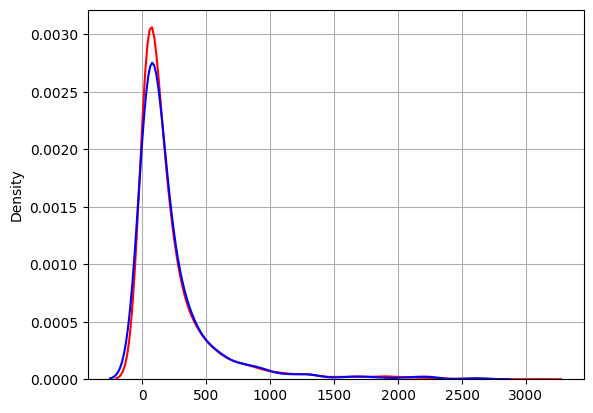

In [6]:
LDA2=[]  #Aquí van a quedar los 1000 datos

for j in range(5):
  LDA2.extend(random.choices(Boxes[j],k=pm[j]))

LDA2=np.array(LDA2)

#Se comprueban las métricas estadísticas
uo=np.mean(LDA)
print("la media de los datos observados es:",uo)
ue=np.mean(LDA2)
print("la media de los datos externos es:",ue)
du=np.abs((uo-ue)/uo)
print("El error relativo porcentual es:",du*100)

plt.figure()
sns.kdeplot(LDA,color='red',label='Datos Observados')
sns.kdeplot(LDA2,color='blue',label='Datos Externos')
plt.grid()
plt.show()
#

**Análisis de Resultados**
De acuerdo con el método de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (Datos Observados:LDA, Datos Externos:LDA2) estuvo por debajo del 5% en promedio, lo que indica que el 95% de los datos aproximadamente fueron correctamente seleccionados. Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimación de las pérdidas por dejar contenedores en tierra. Es importante mencionar que las medias de los datos observadoes y los externos fueron bla, bla, bla, las desviaciones fueron bla, bla, bla, los coeficientes asimetría fueron tales y tales, y la curtosis fueron tales y tales (es que fueron muy similares).

**Integración datos COSCO (datos externos)**
En esta parte, la naviera EVERGREEN quiere integrar los datos logisticos de la operación de COSCO Shipping. Para lo cual usará el modelos K-Medoids

1. Se carga la base de datos COSCO Shipping (base de datos externa)

,Mensual,Transacción Mensuales (Mes),Valor Transado (MUSD),Eventos (Mes),Severidad (KUSD)
0,1,16,16.840771,1,0.971171
1,2,66,31.694407,8,2.267038
2,3,127,16.901201,10,0.975352
3,4,113,25.340976,11,4.453477
4,5,192,24.096199,16,2.937216
...,...,...,...,...,...
495,496,22,11.492619,2,1.471331
496,497,91,41.608338,3,2.618779
497,498,29,54.306981,3,5.996600
498,499,126,143.389211,19,15.343642


la media de los externos es: 60.70724412540753
El coeficiente de asimetría es: 3.1642367700246283
El coeficiente de curtosis es: 12.024762972960977


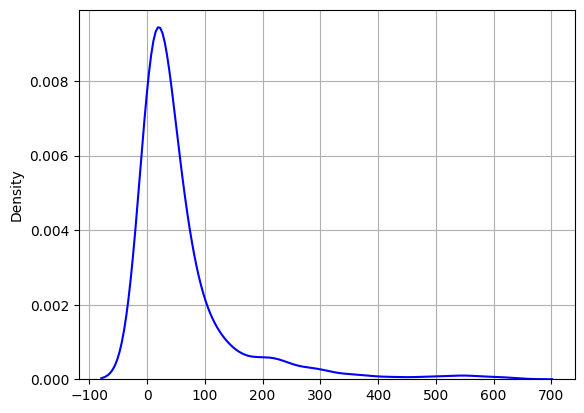

In [11]:
import pandas as pd
import seaborn as sns

nxle='/3. Datos COSCO Shipping.xlsx'
XDBe = pd.read_excel(nxle)
display(XDBe)

Freqe = XDBe.iloc[:, 3]
Seve = XDBe.iloc[:, 4]
LDAe = Freqe * Seve
print("la media de los externos es:",np.mean(LDAe))
print("El coeficiente de asimetría es:",LDAe.skew())
print("El coeficiente de curtosis es:",LDAe.kurtosis())


plt.figure()
sns.kdeplot(LDAe,color='blue')
plt.grid()
plt.show()



2. se procede con la integración de datos externos

In [17]:
LDAe = np.array(LDAe)

VP = np.exp(-0.5*((XC-LDAe[0,])/XC)**2)   #A cual caja pertenece el dato
print("Los valores de pertenencia a los clusters internos son:",VP)


if np.max(VP)>0.90:
  print("Se integra el dato")

Los valores de pertenencia a los clusters internos son: [0.7427239  0.66798859 0.62986913 0.61261248 0.6074849 ]
